<a href="https://colab.research.google.com/github/camilodel02/Supervised-Learning/blob/main/DecisionTreeHeartDesease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Árboles de decisión
###**Objetivo y mecanismo:** Tarea de clasificación/estimación que realiza particiones particiones recursivas de las variables predictoras en un conjunto de rectángulos
**Ventajas:**
- Interpretabilidad
- Flexibilidad
- Manejo de interacciones

**Desventajas:**
- Inestabilidad de árboles
- Variables con muchas categorías
- Riesgo de overfitting dependiendo del tamaño del árbol

###Técnicas:
- **CHAID:** Basada en tablas de contingencia (Chi-cuadrado). Detiene el crecimiento del árbol basado en p values. Debe ajustar por Bonferroni.
- **CART:** Basada en algoritmos. Crea el árbol completo y luego lo reduce (poda) hasta hallar el árbol que minimiza el error de clasificación (métrica de impureza) dado un tamaño de árbol basado en costo de la complejidad (# de ramas). Se debe definir el criterio de poda de error en el riesgo. Usa un hiperparámetro de costo de complejidad **alpha**

###Métricas de impurezas:
**Information gain** (basado en teoría de la información - entropía)

**Índice Gini**

**Error de clasificación** (para podar solamente - no diferenciable)

##Ejemplo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Analítica/Archivos de trabajo/heart_decisionTree.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


###EDA

In [ ]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
print(data['ChestPainType'].unique())

['ATA' 'NAP' 'ASY' 'TA']


In [ ]:
print(data['RestingECG'].unique())

['Normal' 'ST' 'LVH']


In [ ]:
data['Sex']=data['Sex'].map({'F':0,'M':1})

In [ ]:
data['ST_Slope']=data['ST_Slope'].map({'Up':0,'Flat':1,'Down':2})

In [ ]:
data['ExerciseAngina']=data['ExerciseAngina'].map({'N':0,'Y':1})

In [ ]:
data['RestingECG']=data['RestingECG'].map({'Normal':0,'ST':1,'LVH':2})

In [ ]:
data['ChestPainType']=data['ChestPainType'].map({'ATA':0,'NAP':1,'ASY':2,'TA':3})

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


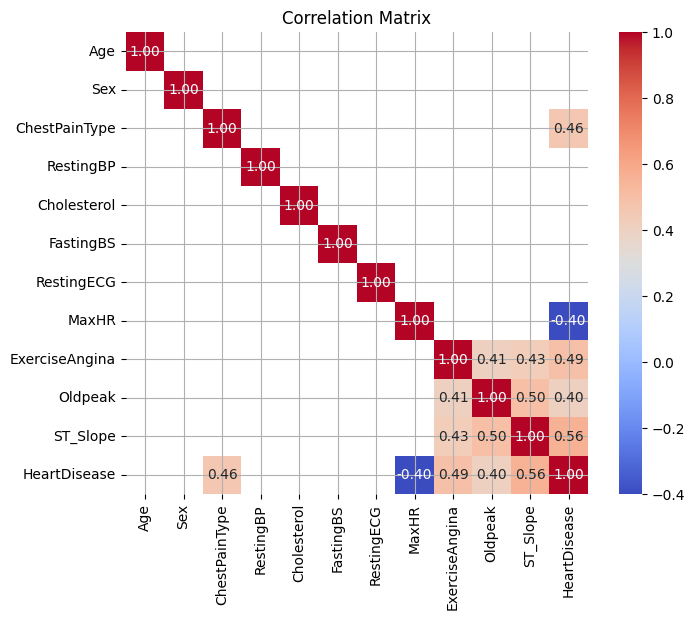

In [ ]:
#Correlation matrix
matrix=data.corr()

filtered_matrix= matrix.copy()
filtered_matrix[np.abs(filtered_matrix)<=0.4]=np.nan

# Graficar
plt.figure(figsize=(8,6))
plt.grid(True)
sns.heatmap(filtered_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, mask=filtered_matrix.isnull())
plt.title('Correlation Matrix')
plt.show()

###Data preprocessing

In [ ]:
x=data.drop('HeartDisease',axis=1)
y=data['HeartDisease']

In [ ]:
#Normalizar
y.value_counts(normalize=True)

,proportion
HeartDisease,
1,0.553377
0,0.446623


##Modeling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

###Logistic Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(X_train)
X_test_sc=sc.transform(X_test)

In [ ]:
LogR_model=LogisticRegression()
LogR_model.fit(X_train_sc,y_train)
y_pred=LogR_model.predict(X_test_sc)

In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}\n')
print(f'Coefficients: {LogR_model.coef_}\n')
print(f'Intercept: {LogR_model.intercept_}')

Accuracy score: 0.8369565217391305

Coefficients: [[ 0.05051388  0.46231999  0.53898054  0.00488057 -0.42098936  0.35429655
   0.0628371  -0.26830963  0.68018528  0.43190644  0.92200958]]

Intercept: [0.32010494]


###SVM

In [ ]:
SVM_model=svm.SVC()
SVM_model.fit(X_train_sc,y_train)
y_pred=SVM_model.predict(X_test_sc)

In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}\n')


Accuracy score: 0.8641304347826086



###Naive Bayes

In [ ]:
NB_model=GaussianNB()
NB_model.fit(X_train_sc,y_train)
y_pred=NB_model.predict(X_test_sc)

In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}\n')

Accuracy score: 0.8369565217391305



###KNN

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning

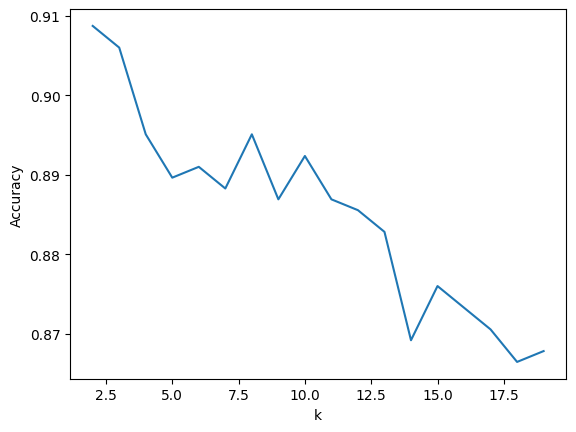

In [ ]:
#Train
distancia=[]
for i in range(2,20):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_sc,y_train)
  y_pred=knn.predict(X_test)
  distancia.append(knn.score(X_train_sc, y_train))

plt.plot(range(2,20),distancia)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning

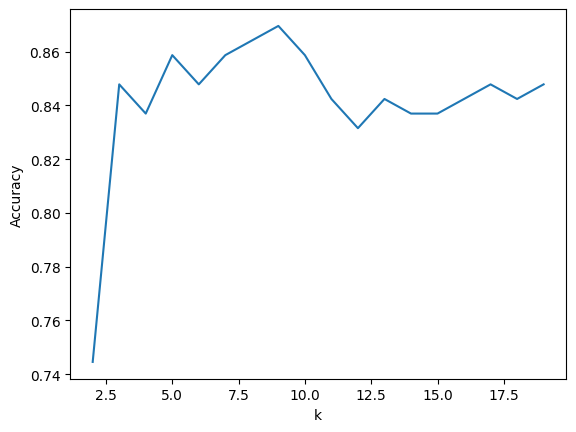

In [ ]:
#Test
distancia=[]
for i in range(2,20):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_sc,y_train)
  y_pred=knn.predict(X_test)
  distancia.append(knn.score(X_test_sc, y_test))

plt.plot(range(2,20),distancia)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
knn_vf=KNeighborsClassifier(n_neighbors=8)
knn_vf.fit(X_train_sc,y_train)
y_pred_knn=knn_vf.predict(X_test_sc)

In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred_knn)}\n')

Accuracy score: 0.8641304347826086



###Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
arbol= DecisionTreeClassifier(max_depth=5, max_features=8) #max_depth da la cantidad de decisiones que se quieren hacer y max features la cantidad de variables (características) más relevantes
arbol.fit(X_train_sc,y_train)
y_pred_arbol=arbol.predict(X_test_sc)


In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred_arbol)}\n')

Accuracy score: 0.8586956521739131



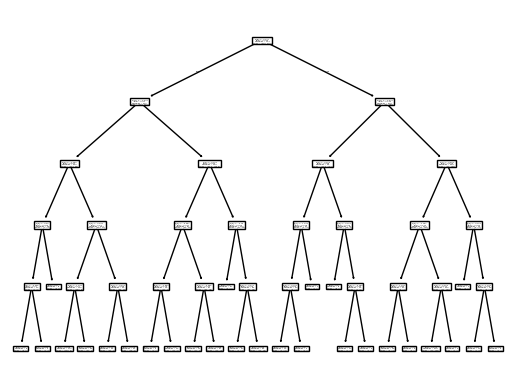

In [ ]:
plot_tree(arbol)
plt.show()

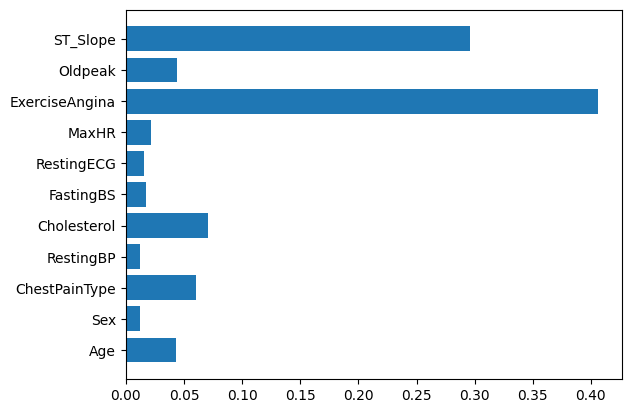

In [ ]:
plt.barh(X_train.columns,arbol.feature_importances_)
plt.show()